<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/focal_cosine_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [3]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


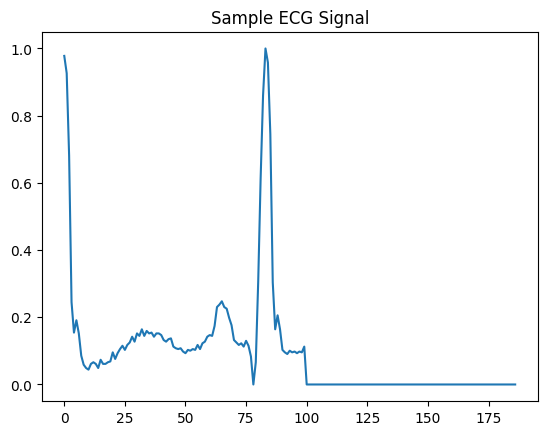

In [4]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

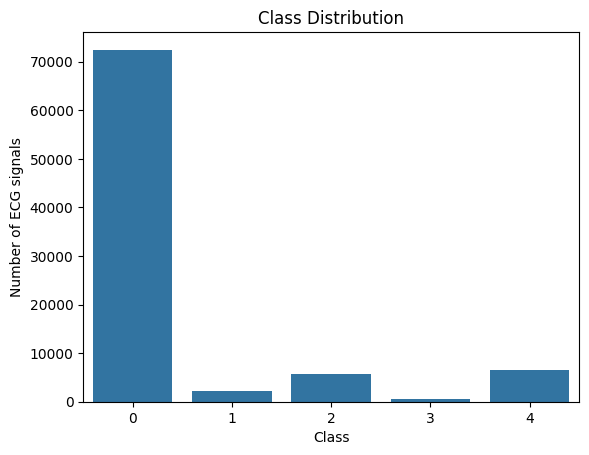

In [5]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [6]:
print("Missing values train:",train.isna().sum().sum())
print("Missing values test:",test.isna().sum().sum())

Missing values train: 0
Missing values test: 0


In [7]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [8]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [10]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [11]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [12]:
def focal_cosine_loss(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)

    # Cosine similarity
    y_true_norm = tf.nn.l2_normalize(y_true, axis=1)
    y_pred_norm = tf.nn.l2_normalize(y_pred, axis=1)
    cosine_sim = tf.reduce_sum(y_true_norm * y_pred_norm, axis=1)

    cosine_loss = 1 - cosine_sim

    # Focal component
    gamma = 2.0
    focal_weight = tf.pow(1 - cosine_sim, gamma)

    loss = focal_weight * cosine_loss

    return tf.reduce_mean(loss)


def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=focal_cosine_loss,
        metrics=['accuracy']
    )

    return model

In [13]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 376s 98ms/step - accuracy: 0.9381 - loss: 0.0111
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 382s 98ms/step - accuracy: 0.9728 - loss: 0.0041
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 369s 98ms/step - accuracy: 0.9795 - loss: 0.0029
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 375s 96ms/step - accuracy: 0.9839 - loss: 0.0022
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 363s 96ms/step - accuracy: 0.9865 - loss: 0.0018

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 371s 97ms/step - accuracy: 0.9413 - loss: 0.0105
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 366s 97ms/step - accuracy: 0.9734 - loss: 0.0039
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 380s 96ms/step - accuracy: 0.9808 - loss: 0.0028
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 368s 98ms/step - accuracy: 0.9840 - loss: 0.0022
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 364s 96ms/step - accuracy: 0.9868 - loss: 0.0018

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 367s 96ms/step - accuracy: 0.9434 -

In [14]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [16]:
model = mobilenet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 488s 106ms/step - accuracy: 0.9487 - loss: 0.0092 - val_accuracy: 0.9369 - val_loss: 0.0110
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 481s 106ms/step - accuracy: 0.9776 - loss: 0.0034 - val_accuracy: 0.8881 - val_loss: 0.0221
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 483s 102ms/step - accuracy: 0.9835 - loss: 0.0024 - val_accuracy: 0.9815 - val_loss: 0.0026
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 458s 101ms/step - accuracy: 0.9867 - loss: 0.0019 - val_accuracy: 0.9288 - val_loss: 0.0100
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 516s 104ms/step - accuracy: 0.9892 - loss: 0.0015 - val_accuracy: 0.8469 - val_loss: 0.0291
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 483s 100ms/step - accuracy: 0.9909 - loss: 0.0013 - val_accuracy: 0.9760 - val_loss: 0.0032
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 454s 100ms/step - accuracy: 0.9915 - loss: 0.0012 - val_accuracy: 0.7379 - val_loss: 0.1403
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 510s 102ms/step - ac

In [17]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)

val_mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", val_mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step
Validation MCC: 0.9904111310363874


Final Training Accuracy: 0.99347323179245
Final Validation Accuracy: 0.9923279881477356


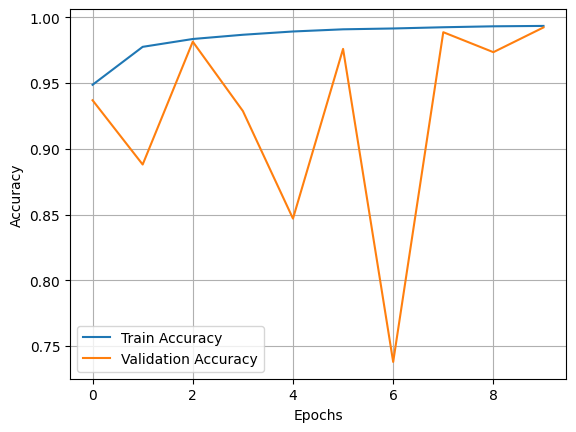

In [18]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Final Training Loss: 0.0009180636261589825
Final Validation Loss: 0.0011824063258245587


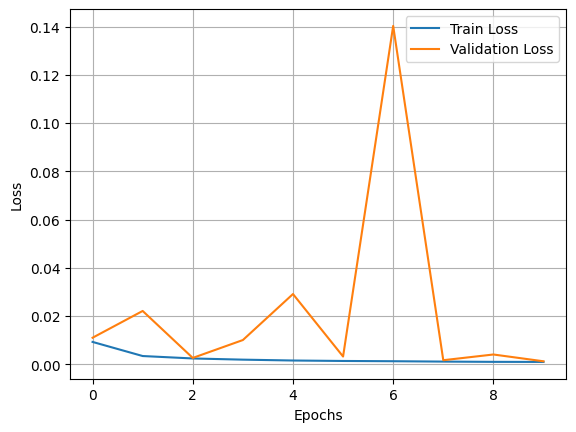

In [19]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

# ===============================
# Classification Report + Specificity
# ===============================

report = classification_report(y_test, y_test_pred, output_dict=True)
cm = confusion_matrix(y_test, y_test_pred)

print("\n{:<10} {:<10} {:<10} {:<10} {:<10} {:<10}".format(
    "Class", "Precision", "Recall", "F1-score", "Specificity", "Support"
))

specificities = []

for i, label in enumerate(report.keys()):
    if label not in ['accuracy', 'macro avg', 'weighted avg']:

        precision = report[label]['precision']
        recall = report[label]['recall']
        f1 = report[label]['f1-score']
        support = int(report[label]['support'])

        TN = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        FP = np.sum(cm[:, i]) - cm[i, i]
        specificity = TN / (TN + FP + 1e-7)

        specificities.append(specificity)

        print("{:<10} {:<10.2f} {:<10.2f} {:<10.2f} {:<10.2f} {:<10}".format(
            label, precision, recall, f1, specificity, support
        ))

print("\nAccuracy:", report['accuracy'])
print("Macro Avg Specificity:", np.mean(specificities))

Test Loss: 0.005393217783421278
Test Accuracy: 0.9778001308441162
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step

Class      Precision  Recall     F1-score   Specificity Support   
0.0        0.99       0.99       0.99       0.95       18118     
1.0        0.70       0.77       0.73       0.99       556       
2.0        0.96       0.95       0.96       1.00       1448      
3.0        0.77       0.88       0.82       1.00       162       
4.0        0.99       0.98       0.99       1.00       1608      

Accuracy: 0.9778001096290883
Macro Avg Specificity: 0.9871333352826996


In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

Test Loss: 0.005393217783421278
Test Accuracy: 0.9778001308441162
685/685 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.70      0.77      0.73       556
         2.0       0.96      0.95      0.96      1448
         3.0       0.77      0.88      0.82       162
         4.0       0.99      0.98      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.88      0.91      0.90     21892
weighted avg       0.98      0.98      0.98     21892



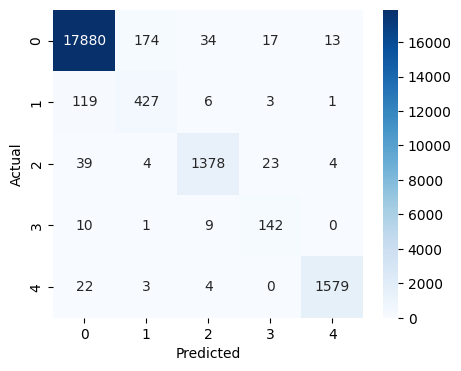

In [22]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()